# EDA: hospedagem e criminalidade em Rio de Janeiro

Análise exploratória conjunta dos datasets de Airbnb e crimes.

In [1]:
from pathlib import Path
%pip install -q geopandas
import geopandas as gpd
import pandas as pd

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "data").is_dir()
)
DATA_DIR = PROJECT_ROOT / "data"

c:\Users\rafamega\Documents\GitHub\Grupo-2\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
listings = pd.read_csv("../../data/listings.csv")
listings

C:\Users\rafamega\AppData\Local\Temp\ipykernel_15300\3338355115.py:1: DtypeWarning: Columns (0: host_profile_url, 1: price, 2: price_quote_checkin_date, 3: price_quote_checkout_date, 4: price_quote_raw, 5: neighborhood_overview, 6: host_since, 7: host_response_time, 8: host_response_rate, 9: host_acceptance_rate, 10: host_thumbnail_url, 11: host_neighbourhood, 12: host_verifications, 13: neighbourhood, 14: instant_bookable) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv("../../data/listings.csv")


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_thumbnail_url,host_neighbourhood,host_total_listings_count,host_verifications,neighbourhood,instant_bookable
0,1025196153924029661,https://www.airbnb.com/rooms/1025196153924029661,20260624212719,2026-06-25,city scrape,Quartos disponíveis no Recreio,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,546603190,https://www.airbnb.com/users/show/546603190,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1697400829368754530,https://www.airbnb.com/rooms/1697400829368754530,20260624212719,2026-06-25,city scrape,Casa próxima a Floresta da Tijuca,Take a break to relax in this serene oasis in ...,https://a0.muscache.com/pictures/hosting/Hosti...,737983482,https://www.airbnb.com/users/show/737983482,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,42874066,https://www.airbnb.com/rooms/42874066,20260624212719,2026-06-25,city scrape,Alugo uma vaga para sexo feminino Recreio,NaN,https://a0.muscache.com/pictures/43e779d6-58df...,341395950,https://www.airbnb.com/users/show/341395950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1543530193994981165,https://www.airbnb.com/rooms/1543530193994981165,20260624212719,2026-06-26,previous scrape,Barra Vista maravilhosa,"Kick back and relax in this calm, stylish space.",https://a0.muscache.com/pictures/hosting/Hosti...,173836079,https://www.airbnb.com/users/show/173836079,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,831750365913119274,https://www.airbnb.com/rooms/831750365913119274,20260624212719,2026-06-25,city scrape,Suíte Rio BR,Spacious and pleasant suite in a family home.,https://a0.muscache.com/pictures/miso/Hosting-...,69238992,https://www.airbnb.com/users/show/69238992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179632,1651790928149305935,https://www.airbnb.com/rooms/1651790928149305935,20260330062336,2026-04-02,city scrape,Av. Atlântica | Vista Mar Incrível | Suíte Premi,"Comfortable sea-facing suite in Copacabana, on...",https://a0.muscache.com/pictures/hosting/Hosti...,357078569,https://www.airbnb.com/users/show/357078569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179633,1652082025241101165,https://www.airbnb.com/rooms/1652082025241101165,20260330062336,2026-04-02,city scrape,Copacabana: Praia e Conforto | 5 Hóspedes,NaN,https://a0.muscache.com/pictures/prohost-api/H...,12335830,https://www.airbnb.com/users/show/12335830,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179634,1652148096386184589,https://www.airbnb.com/rooms/1652148096386184589,20260330062336,2026-04-02,city scrape,Amplo e bem localizado Apê em Copacabana,"Spacious apartment in Copacabana, just minutes...",https://a0.muscache.com/pictures/hosting/Hosti...,513633037,https://www.airbnb.com/users/show/513633037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179635,1652264749683808805,https://www.airbnb.com/rooms/1652264749683808805,20260330062336,2026-04-02,city scrape,Apartamento para trabalho e para casal,Keep it simple at this peaceful and centrally-...,https://a0.muscache.com/pictures/hosting/Hosti...,754155809,https://www.airbnb.com/users/show/754155809,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,anuncios,com_preco,com_preco_cotacao,pct_com_preco
snapshot (início),,,,
26/09/2025,43068,38670,0,89.8
28/12/2025,47087,0,0,0.0
30/03/2026,40769,39816,39811,97.7
24/06/2026,48713,44542,44542,91.4


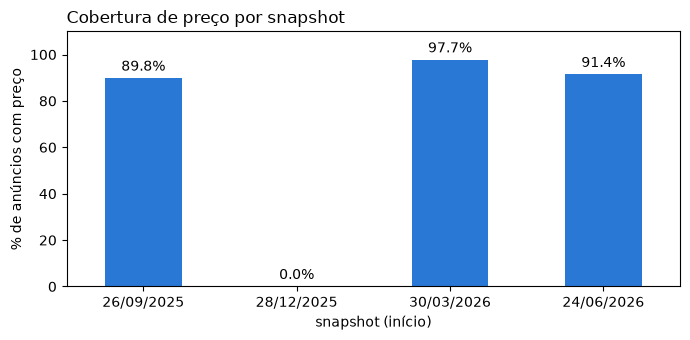

In [3]:
import matplotlib.pyplot as plt

# Cobertura de preço por snapshot: o preço vem vazio em parte dos anúncios, e em dez/25 vem 100% vazio.
cobertura_preco = listings.groupby("scrape_id").agg(
    anuncios=("id", "size"),
    com_preco=("price", "count"),
    com_preco_cotacao=("price_quote_price_per_night", "count"),
)
cobertura_preco["pct_com_preco"] = (cobertura_preco["com_preco"] / cobertura_preco["anuncios"] * 100).round(1)
cobertura_preco.index = pd.to_datetime(cobertura_preco.index.astype(str).str[:8]).strftime("%d/%m/%Y")
cobertura_preco.index.name = "snapshot (início)"
display(cobertura_preco)

ax = cobertura_preco["pct_com_preco"].plot.bar(figsize=(7, 3.5), color="#2a78d6", rot=0)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_ylim(0, 110)
ax.set_ylabel("% de anúncios com preço")
ax.set_title("Cobertura de preço por snapshot", loc="left")
plt.tight_layout()
plt.show()

In [4]:
crimes = pd.read_csv("../../data/crime_data/BaseDPEvolucaoMensalCisp.csv", encoding="latin-1", sep=";")
crimes

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38131,159,7,2026,2026m07,11,7,Cachoeiras de Macacu,3300803,Interior,0,...,3.0,0.0,21,3,0,0,0,0,148,2
38132,165,7,2026,2026m07,33,5,Mangaratiba,3302601,Interior,2,...,8.0,0.0,40,1,0,0,0,0,180,2
38133,166,7,2026,2026m07,33,5,Angra dos Reis,3300100,Interior,3,...,21.0,3.0,96,4,0,0,0,0,710,2
38134,167,7,2026,2026m07,43,5,Paraty,3303807,Capital,1,...,3.0,0.0,27,2,1,0,0,0,206,2


In [5]:
cisp = gpd.read_file(
    "../../data/shape_file/CISPshp/CISPshp/cisp.shp"
)

aisp = gpd.read_file(
    "../../data/shape_file/AISPshp/SHP/aisp.shp"
)

risp = gpd.read_file(
    "../../data/shape_file/RISPshp/RISPshp/risp.shp"
)

# Merge Datasets

Crimes (somados por trimestre em cada CISP da capital) e anúncios (localizados na CISP por spatial join, com o trimestre dado pelo `scrape_id`) são unidos por CISP, ano e trimestre.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Cada scrape_id é um snapshot inteiro. O trimestre vem do início do scrape:
# last_scraped atravessa a virada do trimestre e misturaria snapshots.
SNAPSHOT_PERIODS = {
    20250926170004: (2025, 3),
    20251228222302: (2025, 4),
    20260330062336: (2026, 1),
    20260624212719: (2026, 2),
}

# Níveis de gravidade, do mais grave (4) ao menos grave (1).
# Só colunas sem sobreposição: total_roubos já contém roubo_rua & cia., e
# letalidade_violenta já contém cvli. Fora: culposos (trânsito), tráfico/APF/
# apreensões (atividade policial, não incidência), desaparecidos e registro_ocorrencias.
TIER_NAMES = {
    4: "Contra a vida / sexual",
    3: "Roubos",
    2: "Violência interpessoal",
    1: "Patrimonial sem violência",
}
TIER_COLUMNS = {
    4: ["letalidade_violenta", "tentat_hom", "feminicidio", "tentativa_feminicidio",
        "estupro", "sequestro", "sequestro_relampago", "extorsao"],
    3: ["total_roubos"],
    2: ["lesao_corp_dolosa", "ameaca"],
    1: ["total_furtos", "estelionato"],
}
WEIGHTS = {4: 4, 3: 3, 2: 2, 1: 1}

ROOM_TYPE = "Entire home/apt"     # controla o tipo de imóvel
MIN_LISTINGS = 20                 # anúncios mínimos por CISP x snapshot
OUTLIER_QUANTILES = (0.01, 0.99)  # corte de preço por snapshot
N_BOOT = 2000

crime_columns = [c for cols in TIER_COLUMNS.values() for c in cols]
assert len(crime_columns) == len(set(crime_columns)), "coluna repetida entre níveis"

In [7]:
# Crimes - mês a mês por CISP (estado inteiro)
# Listings - 4 snapshots trimestrais com coordenadas
# Shapefile - CISP (traz areakm2); AISP/RISP não são necessários para o merge


def normalize_area_id(frame, columns):
    frame = frame.copy()
    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce").astype("Int64")
    return frame


# Crimes: só a capital, uma linha por CISP x mês, somados por trimestre.
crimes_rio = normalize_area_id(crimes, ["cisp"]).query("munic == 'Rio de Janeiro'")
assert not crimes_rio.duplicated(["cisp", "ano", "mes"]).any()
crimes_rio = crimes_rio.assign(trimestre=(crimes_rio["mes"] - 1) // 3 + 1)

crimes_quarterly = (
    crimes_rio.groupby(["cisp", "ano", "trimestre"], as_index=False)
    .agg(meses=("mes", "nunique"), **{c: (c, "sum") for c in crime_columns})
    .query("meses == 3")  # descarta trimestre incompleto (2026 T3 só tem julho)
    .drop(columns="meses")
)
for nivel, colunas in TIER_COLUMNS.items():
    crimes_quarterly[f"crimes_nivel{nivel}"] = crimes_quarterly[colunas].sum(axis=1)

# Listings: trimestre pelo scrape_id, coordenadas -> pontos.
listing_columns = ["id", "scrape_id", "latitude", "longitude", "price", "room_type", "accommodates", "bedrooms"]
snapshots = pd.DataFrame.from_dict(SNAPSHOT_PERIODS, orient="index", columns=["ano", "trimestre"])
listing_points = listings[listing_columns].merge(
    snapshots, left_on="scrape_id", right_index=True, how="left", validate="many_to_one"
)
assert listing_points["ano"].notna().all(), "scrape_id sem trimestre definido em SNAPSHOT_PERIODS"
listing_points = listing_points.dropna(subset=["latitude", "longitude"])
listing_points = gpd.GeoDataFrame(
    listing_points,
    geometry=gpd.points_from_xy(listing_points["longitude"], listing_points["latitude"]),
    crs="EPSG:4326",
)

# Um único sjoin com a CISP (traz a área em km²).
cisp_area = normalize_area_id(cisp, ["cisp"])[["cisp", "areakm2", "geometry"]]
listings_cisp = gpd.sjoin(
    listing_points, cisp_area, how="left", predicate="within"
).drop(columns="index_right")
assert len(listings_cisp) == len(listing_points), "sjoin duplicou linhas (polígonos sobrepostos)"
listings_cisp = normalize_area_id(pd.DataFrame(listings_cisp.drop(columns="geometry")), ["cisp"])

listings_crimes = listings_cisp.merge(
    crimes_quarterly,
    on=["cisp", "ano", "trimestre"],
    how="left",
    validate="many_to_one",
)
assert len(listings_crimes) == len(listings_cisp)

# Taxa por nível: crimes por km² no trimestre.
for nivel in TIER_COLUMNS:
    listings_crimes[f"taxa_nivel{nivel}"] = (
        listings_crimes[f"crimes_nivel{nivel}"] / listings_crimes["areakm2"]
    )

print(f"Dimensão de listings_crimes: {listings_crimes.shape[0]:,} linhas x {listings_crimes.shape[1]} colunas")
print(f"Anúncios fora de qualquer CISP: {listings_crimes['cisp'].isna().sum()}")
display(
    listings_crimes.groupby(["ano", "trimestre"]).agg(
        anuncios=("id", "size"),
        com_preco=("price", "count"),
        com_crime=("crimes_nivel1", "count"),
    )
)

Dimensão de listings_crimes: 179,637 linhas x 33 colunas
Anúncios fora de qualquer CISP: 4


anuncios  com_preco  com_crime
ano  trimestre                                
2025 3             43068      38670      43067
     4             47087          0      47086
2026 1             40769      39816      40768
     2             48713      44542      48712

# Crime x preço por nível de gravidade

Para cada CISP e snapshot, calculamos a taxa de crimes por km² em quatro níveis de gravidade e um índice ponderado (pesos 4-3-2-1). Comparamos com a mediana de preço de casas e apartamentos inteiros, relativa à mediana do snapshot, usando Spearman com IC por bootstrap de CISPs.

In [8]:
df = listings_crimes.copy()
df["preco_noite"] = pd.to_numeric(
    df["price"].astype("string").str.replace(r"[$,]", "", regex=True), errors="coerce"
).astype(float)

# Snapshot sem preço não entra na análise de preço (ex.: dez/2025 vem 100% vazio).
cobertura = df.groupby(["ano", "trimestre"])["preco_noite"].agg(anuncios="size", com_preco="count")
sem_preco = cobertura.index[cobertura["com_preco"] == 0].tolist()
if sem_preco:
    print(f"Atenção: snapshots sem nenhum preço, fora da análise: {sem_preco}")

# Só casa/apto inteiro, preço > 0, sem outliers extremos dentro de cada snapshot.
casas = df[(df["room_type"] == ROOM_TYPE) & (df["preco_noite"] > 0) & df["cisp"].notna()].copy()
por_snapshot = casas.groupby(["ano", "trimestre"])["preco_noite"]
piso = por_snapshot.transform(lambda s: s.quantile(OUTLIER_QUANTILES[0]))
teto = por_snapshot.transform(lambda s: s.quantile(OUTLIER_QUANTILES[1]))
casas = casas[(casas["preco_noite"] >= piso) & (casas["preco_noite"] <= teto)]

# Uma linha por CISP x snapshot.
taxa_cols = [f"taxa_nivel{n}" for n in sorted(TIER_COLUMNS, reverse=True)]
analise = (
    casas.groupby(["cisp", "ano", "trimestre"], as_index=False)
    .agg(
        preco_mediano=("preco_noite", "median"),
        anuncios=("id", "size"),
        areakm2=("areakm2", "first"),
        **{c: (c, "first") for c in taxa_cols},
    )
    .query("anuncios >= @MIN_LISTINGS")
    .dropna(subset=taxa_cols)
    .reset_index(drop=True)
)
analise["periodo"] = "T" + analise["trimestre"].astype(str) + "/" + analise["ano"].astype(str)
assert not analise.duplicated(["cisp", "periodo"]).any()

# Os snapshots têm níveis de preço diferentes (sazonalidade/inflação). O preço relativo à
# mediana do snapshot remove esse deslocamento ao juntar os trimestres; dentro de cada
# snapshot o Spearman é idêntico ao do preço absoluto.
analise["preco_relativo"] = analise["preco_mediano"] / analise.groupby("periodo")["preco_mediano"].transform("median")

# Índice de gravidade: média ponderada do ranking percentil de cada nível.
# Ranking (e não log/z-score) porque as taxas por km² variam de <0,1 a >50 e o
# Spearman só depende da ordem de qualquer forma.
ranks = analise[taxa_cols].rank(pct=True)
analise["indice_gravidade"] = (
    sum(WEIGHTS[n] * ranks[f"taxa_nivel{n}"] for n in WEIGHTS) / sum(WEIGHTS.values())
)
analise["indice_pesos_iguais"] = ranks.mean(axis=1)

print(cobertura)
print(f"\nCISP x snapshot na análise: {len(analise)} ({analise['cisp'].nunique()} CISPs distintas)")
print(analise.groupby("periodo").agg(cisps=("cisp", "nunique"), anuncios=("anuncios", "sum")))
print("\nCorrelação (Spearman) entre as taxas de cada nível:")
display(analise[taxa_cols].corr(method="spearman").round(2))
display(analise.sort_values("indice_gravidade").head())

Atenção: snapshots sem nenhum preço, fora da análise: [(2025, 4)]
                anuncios  com_preco
ano  trimestre                     
2025 3             43068      38670
     4             47087          0
2026 1             40769      39816
     2             48713      44542

CISP x snapshot na análise: 111 (38 CISPs distintas)
         cisps  anuncios
periodo                 
T1/2026     37     32103
T2/2026     38     35380
T3/2025     36     30615

Correlação (Spearman) entre as taxas de cada nível:


,taxa_nivel4,taxa_nivel3,taxa_nivel2,taxa_nivel1
taxa_nivel4,1.00,0.76,0.90,0.85
taxa_nivel3,0.76,1.00,0.78,0.79
taxa_nivel2,0.90,0.78,1.00,0.89
taxa_nivel1,0.85,0.79,0.89,1.00


,cisp,ano,trimestre,preco_mediano,anuncios,areakm2,taxa_nivel4,taxa_nivel3,taxa_nivel2,taxa_nivel1,periodo,preco_relativo,indice_gravidade,indice_pesos_iguais
105,43,2025,3,350.00,119,155.2,0.309278,1.030928,3.369845,3.576031,T3/2025,1.434426,0.018018,0.018018
107,43,2026,2,563.01,162,155.2,0.335052,0.637887,4.188144,4.349227,T2/2026,1.570165,0.020721,0.022523
106,43,2026,1,547.88,144,155.2,0.489691,0.579897,4.207474,3.331186,T1/2026,1.494082,0.028829,0.024775
92,36,2026,2,221.50,52,152.5,0.583607,1.068852,5.665574,7.455738,T2/2026,0.617736,0.062162,0.063063
90,36,2025,3,195.00,30,152.5,0.622951,1.370492,5.022951,6.950820,T3/2025,0.799180,0.065766,0.060811


In [9]:
def spearman(a, b):
    ra = pd.Series(a).rank().to_numpy()
    rb = pd.Series(b).rank().to_numpy()
    if ra.std() == 0 or rb.std() == 0:
        return np.nan
    return np.corrcoef(ra, rb)[0, 1]


def spearman_bootstrap(frame, x, y, n_boot=N_BOOT, seed=42):
    """Spearman + IC 95% e p-valor por bootstrap, reamostrando CISPs inteiras.

    Reamostrar por CISP respeita que a mesma CISP aparece em vários snapshots
    (as linhas não são independentes). O p-valor é o bootstrap bicaudal.
    """
    rho = spearman(frame[x], frame[y])
    clusters = [g[[x, y]].to_numpy() for _, g in frame.groupby("cisp")]
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(clusters), len(clusters))
        arr = np.concatenate([clusters[i] for i in pick])
        boots.append(spearman(arr[:, 0], arr[:, 1]))
    boots = np.array(boots)
    boots = boots[~np.isnan(boots)]
    low, high = np.percentile(boots, [2.5, 97.5])
    p = min(1.0, 2 * min((boots > 0).mean(), (boots < 0).mean()))
    return rho, low, high, p, len(frame)


alvos = {f"Nível {n} — {TIER_NAMES[n]}": f"taxa_nivel{n}" for n in sorted(TIER_NAMES, reverse=True)}
alvos["Índice de gravidade (pesos 4-3-2-1)"] = "indice_gravidade"
alvos["Índice de gravidade (pesos iguais)"] = "indice_pesos_iguais"

grupos = {"Agrupado": analise}
grupos.update({p: g for p, g in analise.groupby("periodo")})

linhas = []
for nome, coluna in alvos.items():
    for grupo, frame in grupos.items():
        rho, low, high, p, n = spearman_bootstrap(frame, coluna, "preco_relativo")
        linhas.append(
            {"medida": nome, "grupo": grupo, "rho": rho, "ic95_inf": low, "ic95_sup": high, "p_boot": p, "n": n}
        )
resultados = pd.DataFrame(linhas)
display(resultados.round(3))

,medida,grupo,rho,ic95_inf,ic95_sup,p_boot,n
0,Nível 4 — Contra a vida / sexual,Agrupado,-0.032,-0.373,0.332,0.848,111
1,Nível 4 — Contra a vida / sexual,T1/2026,-0.009,-0.404,0.382,0.956,37
2,Nível 4 — Contra a vida / sexual,T2/2026,0.019,-0.360,0.388,0.936,38
3,Nível 4 — Contra a vida / sexual,T3/2025,-0.100,-0.429,0.287,0.571,36
4,Nível 3 — Roubos,Agrupado,-0.064,-0.431,0.290,0.722,111
5,Nível 3 — Roubos,T1/2026,0.028,-0.346,0.377,0.927,37
6,Nível 3 — Roubos,T2/2026,-0.088,-0.481,0.272,0.630,38
7,Nível 3 — Roubos,T3/2025,-0.156,-0.501,0.198,0.397,36
8,Nível 2 — Violência interpessoal,Agrupado,-0.100,-0.450,0.267,0.594,111
9,Nível 2 — Violência interpessoal,T1/2026,-0.038,-0.408,0.347,0.821,37


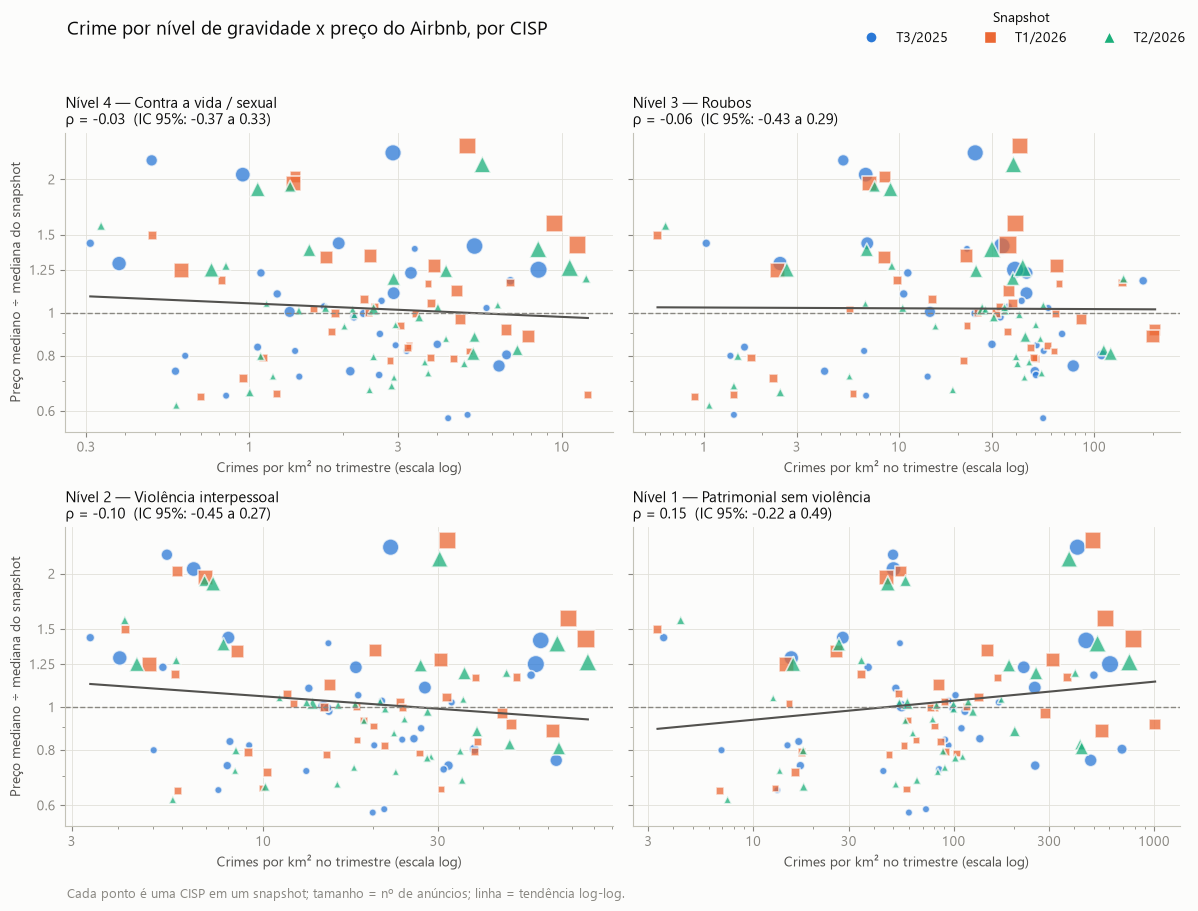

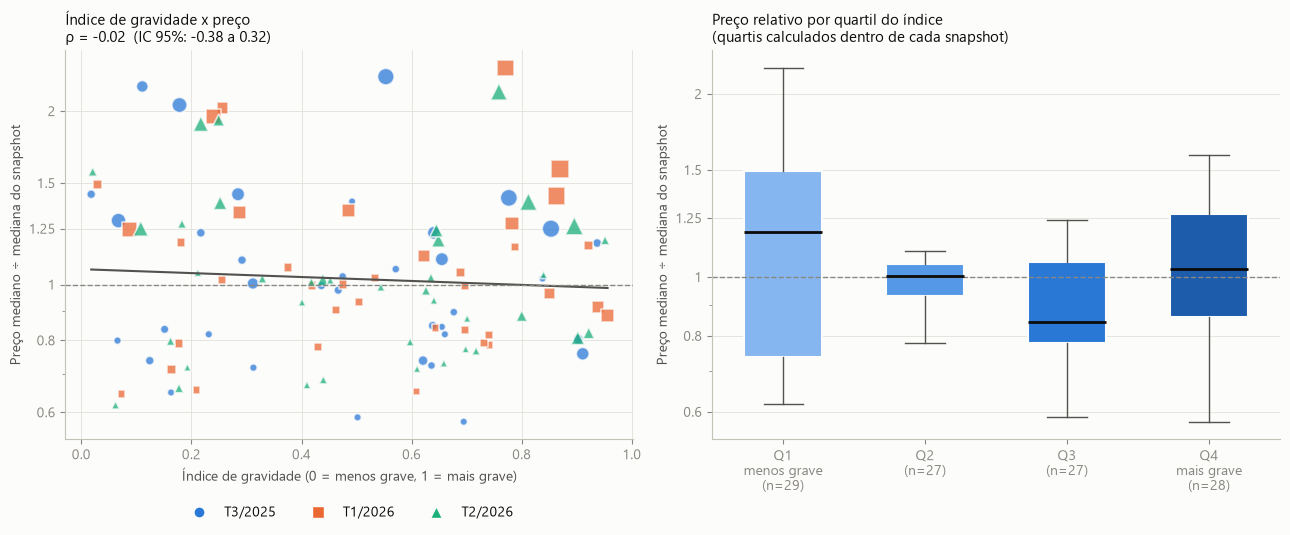

Índice de gravidade x preço (agrupado): ρ = -0.02, IC 95% [-0.38, 0.32] -> o IC inclui zero: sem evidência de relação. Ausência de evidência não é evidência de ausência: com 111 observações o intervalo ainda admite |ρ| de até 0.38.
Atenção: correlação entre áreas (ecológica) não prova que o crime altera o preço, e não controla localização/praia/turismo.


In [10]:
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# Paleta categórica (3 snapshots, validada para todos os pares) + tinta neutra.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "Helvetica", "Arial", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
})
periodos = sorted(analise["periodo"].unique(), key=lambda p: (p[-4:], p[:2]))
cor_periodo = dict(zip(periodos, ["#2a78d6", "#eb6834", "#1baf7a"]))
marca_periodo = dict(zip(periodos, ["o", "s", "^"]))  # forma + cor: não depende só da cor
legenda = [
    Line2D([], [], marker=marca_periodo[p], color=cor_periodo[p], linestyle="", markersize=8,
           markeredgecolor=SURFACE, label=p)
    for p in periodos
]


def rho_texto(medida, grupo="Agrupado"):
    r = resultados[(resultados["medida"] == medida) & (resultados["grupo"] == grupo)].iloc[0]
    return f"ρ = {r['rho']:.2f}  (IC 95%: {r['ic95_inf']:.2f} a {r['ic95_sup']:.2f})"


def eixo_log(axis, ticks):
    axis.set_major_locator(FixedLocator(ticks))
    axis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    axis.set_minor_formatter(NullFormatter())


def dispersao(ax, x, y="preco_relativo", log_x=True):
    for p in periodos:
        d = analise[analise["periodo"] == p]
        tamanho = 20 + 150 * np.sqrt(d["anuncios"] / analise["anuncios"].max())
        ax.scatter(d[x], d[y], s=tamanho, alpha=0.75, marker=marca_periodo[p],
                   color=cor_periodo[p], edgecolor=SURFACE, linewidth=1.2)
    # Tendência ajustada em log-log (ou semi-log no índice): só orientação visual.
    ok = analise[analise[x] > 0]
    xs = np.log(ok[x]) if log_x else ok[x]
    coef = np.polyfit(xs, np.log(ok[y]), 1)
    grade = np.linspace(xs.min(), xs.max(), 100)
    ax.plot(np.exp(grade) if log_x else grade, np.exp(np.polyval(coef, grade)), color=INK_2, linewidth=1.5)
    if log_x:
        ax.set_xscale("log")
        eixo_log(ax.xaxis, [0.3, 1, 3, 10, 30, 100, 300, 1000])
    ax.set_yscale("log")
    eixo_log(ax.yaxis, [0.6, 0.8, 1, 1.25, 1.5, 2])
    ax.axhline(1, color=MUTED, linewidth=1, linestyle="--")
    ax.set_ylabel("Preço mediano ÷ mediana do snapshot")


# Figura 1: um painel por nível de gravidade.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for ax, nivel in zip(axes.flat, sorted(TIER_NAMES, reverse=True)):
    dispersao(ax, f"taxa_nivel{nivel}")
    medida = f"Nível {nivel} — {TIER_NAMES[nivel]}"
    ax.set_title(f"Nível {nivel} — {TIER_NAMES[nivel]}\n{rho_texto(medida)}", fontsize=11, loc="left")
    ax.set_xlabel("Crimes por km² no trimestre (escala log)")
for ax in axes[:, 1]:
    ax.set_ylabel("")
fig.legend(handles=legenda, loc="upper right", frameon=False, ncol=3, title="Snapshot")
fig.suptitle("Crime por nível de gravidade x preço do Airbnb, por CISP", x=0.06, ha="left", fontsize=14)
fig.text(0.06, 0.005, "Cada ponto é uma CISP em um snapshot; tamanho = nº de anúncios; linha = tendência log-log.",
         fontsize=9, color=MUTED)
plt.tight_layout(rect=(0, 0.02, 1, 0.95))
plt.show()

# Figura 2: índice de gravidade (dispersão) e preço relativo por quartil do índice.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
dispersao(ax1, "indice_gravidade", log_x=False)
ax1.set_xlabel("Índice de gravidade (0 = menos grave, 1 = mais grave)")
ax1.set_title(f"Índice de gravidade x preço\n{rho_texto('Índice de gravidade (pesos 4-3-2-1)')}", fontsize=11, loc="left")
ax1.legend(handles=legenda, frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14))

# Quartis do índice calculados dentro de cada snapshot.
rotulos = ["Q1\nmenos grave", "Q2", "Q3", "Q4\nmais grave"]
analise["quartil_indice"] = analise.groupby("periodo")["indice_gravidade"].transform(
    lambda s: pd.qcut(s, 4, labels=rotulos)
).astype(str)
dados = [analise.loc[analise["quartil_indice"] == q, "preco_relativo"] for q in rotulos]
caixas = ax2.boxplot(dados, tick_labels=[f"{q}\n(n={len(d)})" for q, d in zip(rotulos, dados)],
                     patch_artist=True, showfliers=False, widths=0.55)
for caixa, cor in zip(caixas["boxes"], ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]):  # rampa sequencial, ordinal
    caixa.set(facecolor=cor, edgecolor=SURFACE, linewidth=1.5)
for parte in ("whiskers", "caps"):
    plt.setp(caixas[parte], color=INK_2, linewidth=1)
plt.setp(caixas["medians"], color=INK, linewidth=2)
ax2.axhline(1, color=MUTED, linewidth=1, linestyle="--")
ax2.set_yscale("log")
eixo_log(ax2.yaxis, [0.6, 0.8, 1, 1.25, 1.5, 2])
ax2.set_ylabel("Preço mediano ÷ mediana do snapshot")
ax2.set_title("Preço relativo por quartil do índice\n(quartis calculados dentro de cada snapshot)", fontsize=11, loc="left")
ax2.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

# Leitura automática do índice (agrupado), sem limiar arbitrário: usa o IC.
ind = resultados[(resultados["medida"] == "Índice de gravidade (pesos 4-3-2-1)") & (resultados["grupo"] == "Agrupado")].iloc[0]
if ind["ic95_inf"] > 0:
    leitura = "associação positiva: CISPs com crime mais grave tendem a ter preço mais alto."
elif ind["ic95_sup"] < 0:
    leitura = "associação negativa: CISPs com crime mais grave tendem a ter preço mais baixo."
else:
    teto = max(abs(ind["ic95_inf"]), abs(ind["ic95_sup"]))
    leitura = (f"o IC inclui zero: sem evidência de relação. Ausência de evidência não é evidência de ausência: "
               f"com {ind['n']:.0f} observações o intervalo ainda admite |ρ| de até {teto:.2f}.")
print(f"Índice de gravidade x preço (agrupado): ρ = {ind['rho']:.2f}, IC 95% [{ind['ic95_inf']:.2f}, {ind['ic95_sup']:.2f}] -> {leitura}")
print("Atenção: correlação entre áreas (ecológica) não prova que o crime altera o preço, e não controla localização/praia/turismo.")

## Leitura dos resultados

Nenhum nível de gravidade nem o índice tem associação distinguível de zero com o preço (todos os ICs de 95% incluem zero). Os níveis são muito correlacionados entre si (0,76 a 0,90) e a taxa é por km², não per capita.

# Parte 2 — Crime x preço entre imóveis parecidos

A mediana por CISP mistura imóveis de tamanhos diferentes. Aqui agrupamos os anúncios por porte e padrão (K-means, só com dados do Airbnb) e comparamos o preço de imóveis parecidos.

## Variáveis do agrupamento

Porte: hóspedes, quartos, banheiros e camas. Padrão: comodidades e tipo (casa ou apartamento). Ficam de fora preço, localização e comodidades que revelam localização, para o cluster não absorver o efeito que queremos medir.

In [11]:
import json
import re

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 0
SILHOUETTE_SAMPLE = 8000  # a silhueta é O(n²): calculada numa amostra fixa
STABILITY_BOOTSTRAPS = 5
N_BOOT_WCB = 1999

# Um registro por anúncio, com os atributos do último snapshot em que ele aparece
# (os atributos mudam pouco entre coletas: 1% a 8% dos anúncios).
imoveis = (
    listings[listings["room_type"] == ROOM_TYPE]
    .sort_values("last_scraped")
    .drop_duplicates("id", keep="last")
    .set_index("id")
)
comodidades = imoveis["amenities"].map(json.loads)


def tem(padrao):
    regex = re.compile(padrao, re.IGNORECASE)
    return comodidades.map(lambda itens: any(regex.search(item) for item in itens)).astype(int)


# Bloco 1 — porte: quanto o imóvel comporta.
X_porte = pd.DataFrame({
    "log_hospedes": np.log(imoveis["accommodates"]),
    "quartos": imoveis["bedrooms"].clip(upper=5),
    "banheiros": imoveis["bathrooms"].clip(upper=4),
    "camas": imoveis["beds"].clip(upper=8),
})
faltantes = X_porte.isna().mean()
X_porte = X_porte.fillna(X_porte.median())

# Bloco 2 — padrão: comodidades do prédio/unidade e tipo (casa x apartamento).
# Os padrões de busca evitam falsos positivos ("Dishwasher", "Pool table", "Pool view", estacionamento de rua).
CASAS = ["Entire home", "Entire villa", "Entire guesthouse", "Entire cottage", "Entire bungalow", "Entire townhouse"]
X_padrao = pd.DataFrame({
    "log_n_comodidades": np.log1p(comodidades.map(len)),
    "ar_condicionado": tem(r"air conditioning|\bac\b"),
    "elevador": tem(r"\belevator\b"),
    "lavadora": tem(r"\bwasher\b"),
    "piscina": tem(r"\bpool\b(?! table| view)"),
    "academia": tem(r"\bgym\b"),
    "estacionamento": tem(r"(parking|garage).*on premises"),
    "area_de_trabalho": tem(r"dedicated workspace"),
    "churrasqueira": tem(r"\bbbq\b|\bgrill\b"),
    "sauna_ou_jacuzzi": tem(r"sauna|hot tub|jacuzzi"),
    "casa": imoveis["property_type"].isin(CASAS).astype(int),
})

# Comodidades que embutem a LOCALIZAÇÃO ficam de fora do agrupamento (ver texto acima).
EXCLUIDAS_LOCALIZACAO = {
    "acesso à praia (Beach access)": r"beach access",
    "vista para o mar/oceano": r"sea view|ocean view",
    "frente ao mar/à água": r"beachfront|waterfront",
    "vista da montanha": r"mountain view",
    "vista do skyline": r"skyline",
}
excluidas = pd.Series({nome: tem(padrao).mean() for nome, padrao in EXCLUIDAS_LOCALIZACAO.items()})

print(f"Anúncios únicos de casa/apto inteiro: {len(imoveis):,}")
print(f"Dados faltantes no bloco de porte (imputados pela mediana):\n{faltantes.round(3).to_string()}\n")
print("Prevalência das variáveis do bloco de padrão:")
display(X_padrao.drop(columns="log_n_comodidades").mean().round(2).to_frame("prevalência").T)
print("Comodidades EXCLUÍDAS por embutirem localização (prevalência):")
display(excluidas.round(3).to_frame("prevalência").T)

Anúncios únicos de casa/apto inteiro: 49,672
Dados faltantes no bloco de porte (imputados pela mediana):
log_hospedes    0.000
quartos         0.039
banheiros       0.138
camas           0.104

Prevalência das variáveis do bloco de padrão:


,ar_condicionado,elevador,lavadora,piscina,academia,estacionamento,area_de_trabalho,churrasqueira,sauna_ou_jacuzzi,casa
prevalência,0.9,0.5,0.58,0.24,0.14,0.4,0.45,0.12,0.11,0.07


Comodidades EXCLUÍDAS por embutirem localização (prevalência):


,acesso à praia (Beach access),vista para o mar/oceano,frente ao mar/à água,vista da montanha,vista do skyline
prevalência,0.412,0.053,0.107,0.058,0.06


## Baseline: K-means em todas as variáveis

Ponto de partida: um único K-means com porte e padrão juntos, avaliado por silhueta, estabilidade (ARI) e R² do log-preço.

,inercia,silhueta,calinski_harabasz,davies_bouldin,ari_bootstrap,r2_preco
k,,,,,,
2,627516.169,0.223,9305.605,2.182,0.977,0.148
3,547782.105,0.230,8944.801,1.787,0.993,0.203
4,499888.754,0.143,8120.605,1.927,0.982,0.189
5,460231.604,0.184,7685.036,1.727,0.569,0.234
6,426047.183,0.155,7438.183,1.737,0.894,0.226
7,406149.010,0.160,6907.570,1.710,0.722,0.232
8,388208.540,0.164,6522.145,1.713,0.768,0.232


Referência: R² do log-preço usando só o nº de quartos = 0.318


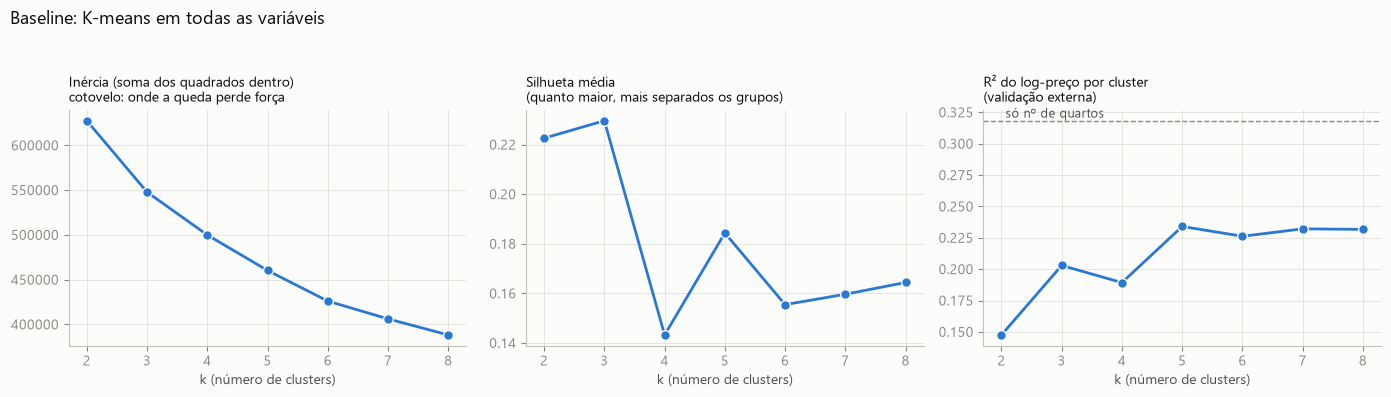

In [12]:
# Validação EXTERNA: quanto da variância do log-preço os grupos explicam. Serve para AVALIAR os
# clusters, nunca para construí-los (usar o preço na construção tornaria a comparação circular).
log_preco_ref = np.log(casas.groupby("id")["preco_noite"].median()).reindex(imoveis.index)


def r2_preco(rotulos):
    d = pd.DataFrame({"y": log_preco_ref.to_numpy(), "g": np.asarray(rotulos)}).dropna()
    soma_dentro = d.groupby("g")["y"].apply(lambda s: ((s - s.mean()) ** 2).sum()).sum()
    return 1 - soma_dentro / ((d["y"] - d["y"].mean()) ** 2).sum()


def diagnosticos(Z, ks):
    rng = np.random.default_rng(RANDOM_STATE)
    amostra = rng.choice(len(Z), SILHOUETTE_SAMPLE, replace=False)
    linhas = []
    for k in ks:
        modelo = KMeans(k, n_init=10, random_state=RANDOM_STATE).fit(Z)
        rotulos = modelo.labels_
        # Estabilidade: ajusta em reamostras bootstrap e compara a partição com a original (ARI).
        ari = [
            adjusted_rand_score(
                rotulos, KMeans(k, n_init=3, random_state=b).fit(Z[rng.choice(len(Z), len(Z))]).predict(Z)
            )
            for b in range(STABILITY_BOOTSTRAPS)
        ]
        linhas.append({
            "k": k,
            "inercia": modelo.inertia_,
            "silhueta": silhouette_score(Z[amostra], rotulos[amostra]),
            "calinski_harabasz": calinski_harabasz_score(Z, rotulos),
            "davies_bouldin": davies_bouldin_score(Z, rotulos),
            "ari_bootstrap": np.mean(ari),
            "r2_preco": r2_preco(rotulos),
        })
    return pd.DataFrame(linhas).set_index("k")


def grafico_diagnosticos(diag, titulo, r2_referencia):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    paineis = [
        ("inercia", "Inércia (soma dos quadrados dentro)\ncotovelo: onde a queda perde força"),
        ("silhueta", "Silhueta média\n(quanto maior, mais separados os grupos)"),
        ("r2_preco", "R² do log-preço por cluster\n(validação externa)"),
    ]
    for ax, (coluna, subtitulo) in zip(axes, paineis):
        ax.plot(diag.index, diag[coluna], color="#2a78d6", linewidth=2, marker="o", markersize=7, markeredgecolor=SURFACE)
        ax.set_title(subtitulo, fontsize=10, loc="left")
        ax.set_xlabel("k (número de clusters)")
        ax.set_xticks(list(diag.index))
    axes[2].axhline(r2_referencia, color=MUTED, linestyle="--", linewidth=1)
    axes[2].text(diag.index[0], r2_referencia, " só nº de quartos", va="bottom", fontsize=9, color=INK_2)
    fig.suptitle(titulo, x=0.01, ha="left", fontsize=13)
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


# Baseline: K-means em TODAS as variáveis, padronizadas.
Z_todas = StandardScaler().fit_transform(pd.concat([X_porte, X_padrao], axis=1))
diag_baseline = diagnosticos(Z_todas, range(2, 9))
r2_quartos = r2_preco(X_porte["quartos"])

display(diag_baseline.round(3))
print(f"Referência: R² do log-preço usando só o nº de quartos = {r2_quartos:.3f}")
grafico_diagnosticos(diag_baseline, "Baseline: K-means em todas as variáveis", r2_quartos)

K_BASELINE = 5
baseline = KMeans(K_BASELINE, n_init=10, random_state=RANDOM_STATE).fit_predict(Z_todas)

### Leitura do baseline

Não há estrutura clara de grupos (silhueta de 0,14 a 0,23) e o R² do preço (até 0,23) fica abaixo do de usar só o número de quartos (0,32).

## Híbrido em duas etapas: porte x padrão

Agrupamos porte e padrão separadamente e usamos o cruzamento como estrato. Os clusters são ordenados por tamanho e por comodidades, nunca pelo preço.

,inercia,silhueta,calinski_harabasz,davies_bouldin,ari_bootstrap,r2_preco
k,,,,,,
2,104732.121,0.482,44559.286,0.922,0.961,0.225
3,76577.683,0.406,39600.946,1.035,0.917,0.282
4,61386.817,0.382,37030.074,0.995,0.857,0.301
5,52769.351,0.406,34334.995,1.077,0.741,0.304
6,45677.982,0.411,33273.780,1.049,0.831,0.317
7,40642.805,0.424,32188.209,1.005,0.837,0.322


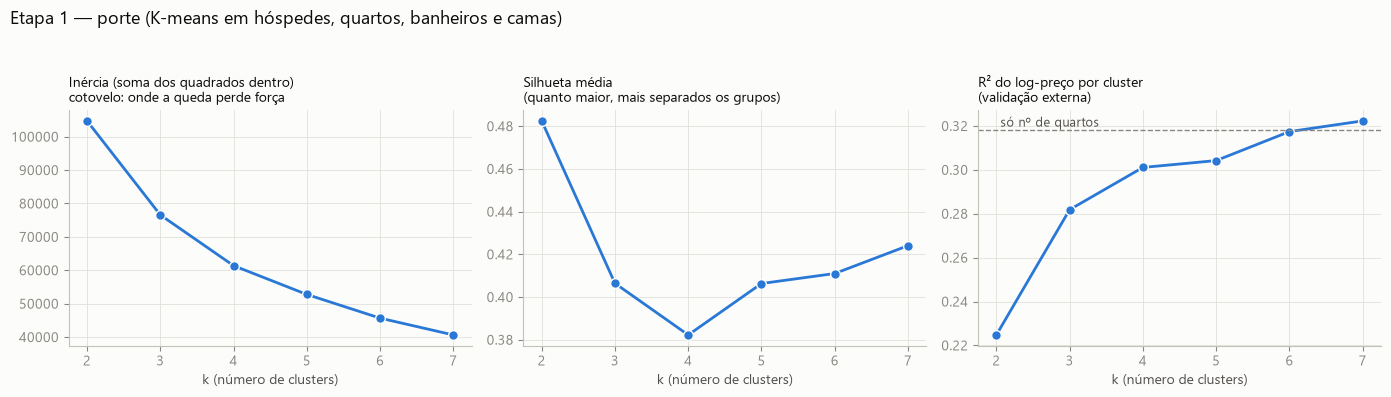

Perfil dos 4 clusters de porte (P1 = menor ... P4 = maior); o preço aparece só como referência:


,anuncios,hospedes,quartos,banheiros,camas,preco_mediano
porte,,,,,,
1,12562,2.0,1.0,1.0,1.0,346.5
2,21275,4.0,1.0,1.0,2.0,408.9
3,12604,5.0,2.0,2.0,3.0,735.0
4,3231,8.0,3.0,3.0,5.0,1455.0


Variância explicada por componente (porte): [0.73 0.13 0.08 0.06]


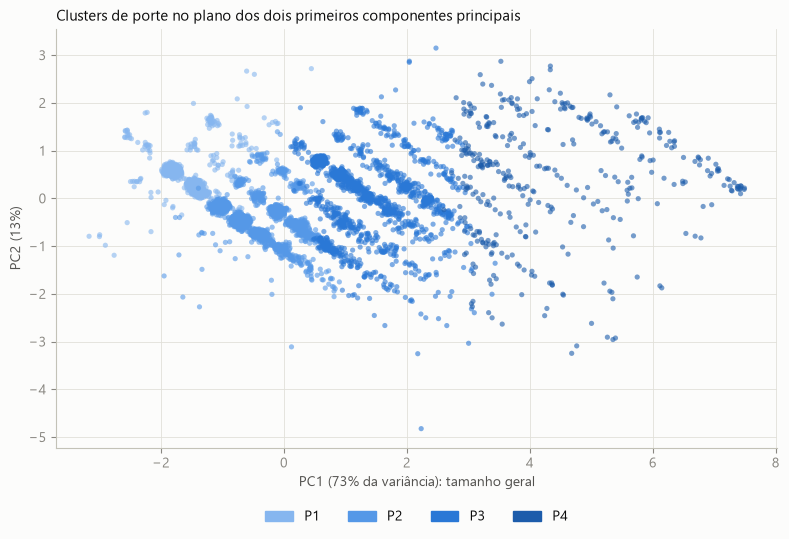

In [13]:
from matplotlib.patches import Patch

# Rampa sequencial azul: porte e padrão são ORDINAIS (menor -> maior), não categorias sem ordem.
RAMPA_ORDINAL = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]


def ordenar_clusters(rotulos, criterio):
    """Renomeia os clusters como 1..k em ordem crescente do critério (que nunca é o preço)."""
    ordem = pd.Series(criterio).groupby(rotulos).mean().sort_values().index
    return pd.Series(rotulos).map({antigo: novo + 1 for novo, antigo in enumerate(ordem)}).to_numpy()


# Etapa 1 — porte: K-means só nas 4 variáveis de tamanho.
Z_porte = StandardScaler().fit_transform(X_porte)
diag_porte = diagnosticos(Z_porte, range(2, 8))
display(diag_porte.round(3))
grafico_diagnosticos(diag_porte, "Etapa 1 — porte (K-means em hóspedes, quartos, banheiros e camas)", r2_quartos)

K_PORTE = 4
km_porte = KMeans(K_PORTE, n_init=10, random_state=RANDOM_STATE).fit(Z_porte)
porte = pd.Series(
    ordenar_clusters(km_porte.labels_, Z_porte.mean(axis=1)), index=imoveis.index, name="porte"
)

perfil_porte = (
    X_porte.assign(porte=porte, preco_mediano=np.exp(log_preco_ref))
    .groupby("porte")
    .agg(
        anuncios=("quartos", "size"),
        hospedes=("log_hospedes", lambda s: np.exp(s).median()),
        quartos=("quartos", "median"),
        banheiros=("banheiros", "median"),
        camas=("camas", "median"),
        preco_mediano=("preco_mediano", "median"),
    )
)
print(f"Perfil dos {K_PORTE} clusters de porte (P1 = menor ... P{K_PORTE} = maior); o preço aparece só como referência:")
display(perfil_porte.round(1))

# PCA: por que o bloco de porte é fácil de agrupar (as 4 variáveis medem quase a mesma coisa).
pca_porte = PCA().fit(Z_porte)
print("Variância explicada por componente (porte):", pca_porte.explained_variance_ratio_.round(2))
coords = pca_porte.transform(Z_porte)[:, :2]
rng = np.random.default_rng(RANDOM_STATE)
amostra = rng.choice(len(coords), 6000, replace=False)
fig, ax = plt.subplots(figsize=(8, 5.5))
for p in range(1, K_PORTE + 1):
    idx = amostra[porte.to_numpy()[amostra] == p]
    ruido = rng.normal(0, 0.06, size=(len(idx), 2))  # as variáveis são discretas: sem ruído os pontos se empilham
    ax.scatter(coords[idx, 0] + ruido[:, 0], coords[idx, 1] + ruido[:, 1], s=14, alpha=0.6,
               color=RAMPA_ORDINAL[p - 1], edgecolor="none")
ax.set_xlabel(f"PC1 ({pca_porte.explained_variance_ratio_[0]:.0%} da variância): tamanho geral")
ax.set_ylabel(f"PC2 ({pca_porte.explained_variance_ratio_[1]:.0%})")
ax.set_title("Clusters de porte no plano dos dois primeiros componentes principais", fontsize=11, loc="left")
ax.legend(handles=[Patch(color=RAMPA_ORDINAL[p - 1], label=f"P{p}") for p in range(1, K_PORTE + 1)],
          frameon=False, ncol=K_PORTE, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()

,inercia,silhueta,calinski_harabasz,davies_bouldin,ari_bootstrap,r2_preco
k,,,,,,
2,441240.020,0.304,11836.916,1.767,0.989,0.030
3,384816.922,0.191,10427.397,1.859,0.983,0.020
4,335919.762,0.210,10373.277,1.633,0.967,0.024
5,299145.895,0.230,10262.541,1.505,0.595,0.030


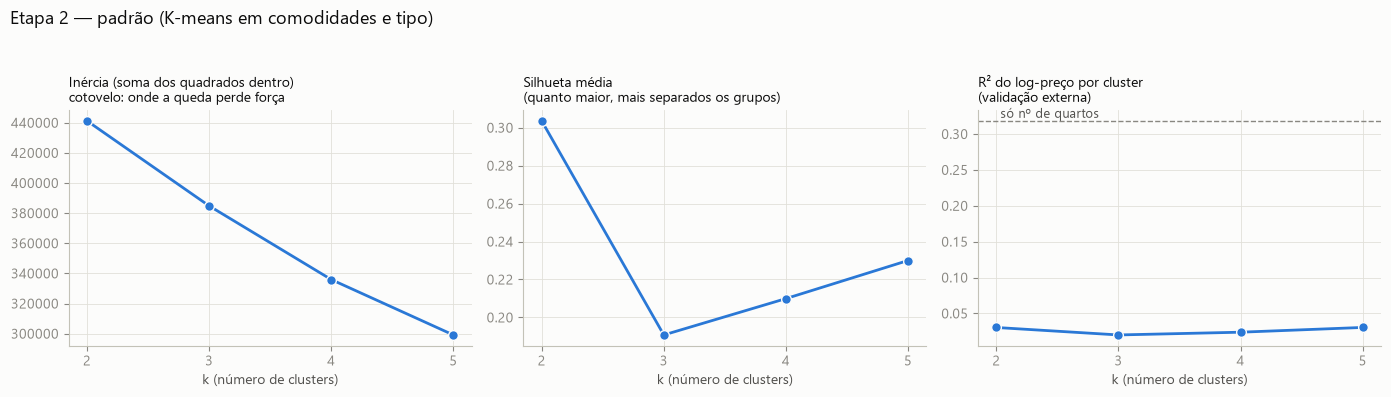

PC1 explica 26% da variância do bloco de padrão. Cargas:


,piscina,academia,sauna_ou_jacuzzi,log_n_comodidades,estacionamento,churrasqueira,elevador,area_de_trabalho,ar_condicionado,lavadora,casa
carga no PC1,0.45,0.43,0.42,0.35,0.34,0.25,0.23,0.19,0.17,0.15,0.02


Perfil dos clusters de padrão (1 = baixo ... 3 = alto); flags = prevalência dentro do cluster:


padrao,1,2,3
anuncios,20050.00,21338.00,8284.00
n_comodidades (média geom.),11.62,29.94,33.55
ar_condicionado,0.81,0.96,0.98
elevador,0.02,0.87,0.73
lavadora,0.52,0.60,0.70
piscina,0.16,0.04,0.93
academia,0.01,0.04,0.71
estacionamento,0.37,0.26,0.83
area_de_trabalho,0.27,0.57,0.58
churrasqueira,0.13,0.02,0.36


In [14]:
# Etapa 2 — padrão: K-means nas comodidades e no tipo (casa x apartamento).
Z_padrao = StandardScaler().fit_transform(X_padrao)
diag_padrao = diagnosticos(Z_padrao, range(2, 6))
display(diag_padrao.round(3))
grafico_diagnosticos(diag_padrao, "Etapa 2 — padrão (K-means em comodidades e tipo)", r2_quartos)

K_PADRAO = 3

# PC1 como índice de "riqueza de comodidades": serve para ORDENAR os clusters (baixo -> alto).
pca_padrao = PCA().fit(Z_padrao)
cargas = pd.Series(pca_padrao.components_[0], index=X_padrao.columns)
if cargas["log_n_comodidades"] < 0:  # o sinal de um componente principal é arbitrário
    cargas = -cargas
pc1 = Z_padrao @ cargas.to_numpy()
print(f"PC1 explica {pca_padrao.explained_variance_ratio_[0]:.0%} da variância do bloco de padrão. Cargas:")
display(cargas.sort_values(ascending=False).round(2).to_frame("carga no PC1").T)

km_padrao = KMeans(K_PADRAO, n_init=10, random_state=RANDOM_STATE).fit(Z_padrao)
padrao = pd.Series(ordenar_clusters(km_padrao.labels_, pc1), index=imoveis.index, name="padrao")

perfil_padrao = X_padrao.assign(padrao=padrao).groupby("padrao").mean()
perfil_padrao["log_n_comodidades"] = np.expm1(perfil_padrao["log_n_comodidades"])
perfil_padrao = perfil_padrao.rename(columns={"log_n_comodidades": "n_comodidades (média geom.)"})
perfil_padrao.insert(0, "anuncios", padrao.value_counts().sort_index())
print("Perfil dos clusters de padrão (1 = baixo ... 3 = alto); flags = prevalência dentro do cluster:")
display(perfil_padrao.round(2).T)

Anúncios por célula (linhas = porte, colunas = padrão):


padrao,1,2,3,All
porte,,,,
1,5467,5290,1805,12562
2,8456,9680,3139,21275
3,4799,5334,2471,12604
4,1328,1034,869,3231
All,20050,21338,8284,49672


,r2_preco,ari_bootstrap
Sem controle,0.000,NaN
Só nº de quartos,0.318,NaN
Baseline: K-means em tudo (k=5),0.234,0.569
Etapa 1: porte (k=4),0.301,0.857
Etapa 2 isolada: padrão (k=3),0.020,0.983
Híbrido: porte x padrão (4x3),0.314,NaN


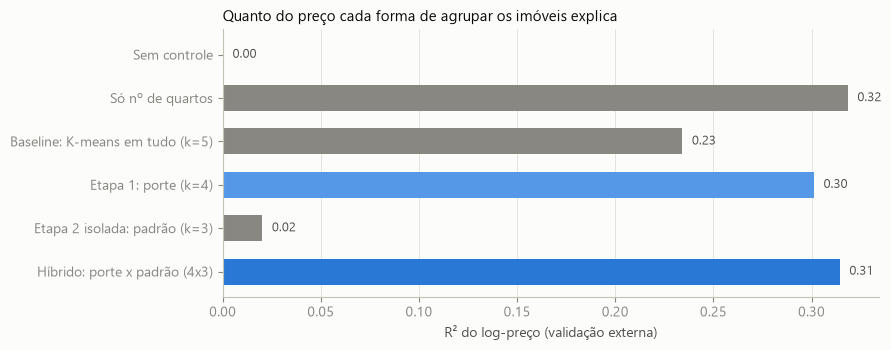

In [15]:
# Cluster final = porte x padrão (4 x 3 = 12 células). Os rótulos do baseline e o nº de quartos ficam
# na mesma tabela para servirem de controles alternativos na regressão.
imoveis_cl = pd.concat([porte, padrao], axis=1)
imoveis_cl["hibrido"] = imoveis_cl["porte"] * 10 + imoveis_cl["padrao"]
imoveis_cl["baseline"] = baseline
imoveis_cl["quartos"] = X_porte["quartos"].to_numpy()
assert imoveis_cl.index.is_unique and imoveis_cl.notna().all().all()

print("Anúncios por célula (linhas = porte, colunas = padrão):")
display(pd.crosstab(imoveis_cl["porte"], imoveis_cl["padrao"], margins=True))

comparacao = pd.DataFrame({
    "r2_preco": {
        "Sem controle": 0.0,
        "Só nº de quartos": r2_quartos,
        f"Baseline: K-means em tudo (k={K_BASELINE})": r2_preco(imoveis_cl["baseline"]),
        f"Etapa 1: porte (k={K_PORTE})": r2_preco(imoveis_cl["porte"]),
        f"Etapa 2 isolada: padrão (k={K_PADRAO})": r2_preco(imoveis_cl["padrao"]),
        f"Híbrido: porte x padrão ({K_PORTE}x{K_PADRAO})": r2_preco(imoveis_cl["hibrido"]),
    },
    "ari_bootstrap": {
        f"Baseline: K-means em tudo (k={K_BASELINE})": diag_baseline.loc[K_BASELINE, "ari_bootstrap"],
        f"Etapa 1: porte (k={K_PORTE})": diag_porte.loc[K_PORTE, "ari_bootstrap"],
        f"Etapa 2 isolada: padrão (k={K_PADRAO})": diag_padrao.loc[K_PADRAO, "ari_bootstrap"],
    },
})
display(comparacao.round(3))

fig, ax = plt.subplots(figsize=(9, 3.6))
cores = [MUTED, MUTED, MUTED, "#5598e7", MUTED, "#2a78d6"]  # ênfase: etapa 1 e híbrido em azul, resto em cinza
barras = ax.barh(comparacao.index[::-1], comparacao["r2_preco"][::-1], color=cores[::-1], height=0.6)
for barra in barras:
    ax.text(barra.get_width() + 0.005, barra.get_y() + barra.get_height() / 2, f"{barra.get_width():.2f}", va="center", fontsize=9, color=INK_2)
ax.set_xlabel("R² do log-preço (validação externa)")
ax.set_title("Quanto do preço cada forma de agrupar os imóveis explica", fontsize=11, loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### Leitura do híbrido

Porte com k = 4 e padrão com k = 3 dão 12 estratos legíveis e R² de 0,31, melhor que o baseline e empatado com o número de quartos (0,32). Quase toda a informação de preço está no porte.

## Crime x preço dentro dos clusters

Regressão de ln(preço) com efeitos fixos de cluster e de snapshot sobre a intensidade de crime da CISP (média ponderada do log da taxa por km²). O erro-padrão é agrupado por CISP (wild cluster bootstrap), porque o crime varia por CISP e o preço por anúncio.

In [16]:
# Intensidade de crime por CISP x snapshot: média ponderada (pesos da Parte 1) do log da taxa por km².
# Contínua (e não o ranking do índice) para permitir interpretar β como elasticidade.
celulas = analise[["cisp", "ano", "trimestre", "periodo"] + taxa_cols].copy()
celulas["log_intensidade"] = sum(
    WEIGHTS[n] * np.log(celulas[f"taxa_nivel{n}"].clip(lower=1e-3)) for n in WEIGHTS
) / sum(WEIGHTS.values())

# Amostra: os mesmos anúncios da Parte 1 (casas, sem outliers, em CISP x snapshot com >= MIN_LISTINGS).
reg = (
    casas[["id", "cisp", "ano", "trimestre", "preco_noite"]]
    .merge(celulas[["cisp", "ano", "trimestre", "periodo", "log_intensidade"]],
           on=["cisp", "ano", "trimestre"], how="inner", validate="many_to_one")
    .join(imoveis_cl, on="id", how="left")
)
reg["cisp"] = reg["cisp"].astype(int)
reg["y"] = np.log(reg["preco_noite"])
assert reg[["porte", "padrao", "hibrido", "baseline", "quartos"]].notna().all().all()
assert reg.groupby(["cisp", "periodo"]).ngroups == len(analise)

dp_x = reg["log_intensidade"].std()
dp_dentro = (reg["log_intensidade"] - reg.groupby("cisp")["log_intensidade"].transform("mean")).std()
print(f"{len(reg):,} linhas anúncio x snapshot em {reg['cisp'].nunique()} CISPs e {reg['periodo'].nunique()} snapshots")
print(f"Desvio-padrão de log_intensidade: {dp_x:.2f} no total, {dp_dentro:.2f} dentro de cada CISP ao longo do tempo")


def residualizar(frame, efeitos):
    """Teorema de Frisch-Waugh-Lovell: β é a inclinação entre os resíduos de y e de x depois de
    remover de ambos a parte explicada pelos efeitos fixos (dummies)."""
    dummies = [pd.get_dummies(frame[e], drop_first=True, dtype=float).to_numpy() for e in efeitos]
    D = np.column_stack([np.ones(len(frame))] + dummies)
    alvo = np.column_stack([frame["y"].to_numpy(), frame["log_intensidade"].to_numpy()])
    residuo = alvo - D @ np.linalg.lstsq(D, alvo, rcond=None)[0]
    return residuo[:, 0], residuo[:, 1]


def estimar(frame, efeitos, n_boot=N_BOOT_WCB):
    """β de ln(preço) em log_intensidade, com EP robusto a cluster (CISP), p e IC por wild cluster bootstrap."""
    yt, xt = residualizar(frame, efeitos)
    codigos, _ = pd.factorize(frame["cisp"])
    G = codigos.max() + 1
    # Tudo o que o estimador precisa são somas POR CLUSTER de x̃·ỹ e x̃².
    sxy = np.bincount(codigos, weights=xt * yt)
    sxx_g = np.bincount(codigos, weights=xt * xt)
    sxx = sxx_g.sum()
    beta = sxy.sum() / sxx
    escores = sxy - beta * sxx_g  # Σ_{i in g} x̃_i û_i, com û = ỹ − β x̃
    ep = np.sqrt(G / (G - 1) * (escores @ escores)) / sxx  # sanduíche com ajuste G/(G−1)
    # Wild cluster bootstrap com pesos de Rademacher por cluster, sob H0: β = β0. Os resíduos restritos
    # são ũ0 = ỹ − β0·x̃, então β* − β0 = Σ_g w_g s0_g / Σx̃² e os escores usam só somas por cluster.
    W = np.random.default_rng(RANDOM_STATE).choice([-1.0, 1.0], size=(n_boot, G))

    def p_wcb(beta0):
        s0 = sxy - beta0 * sxx_g
        delta = W @ s0 / sxx
        escores_b = W * s0 - delta[:, None] * sxx_g
        ep_b = np.sqrt(G / (G - 1) * (escores_b ** 2).sum(axis=1)) / sxx
        return np.mean(np.abs(delta / ep_b) >= abs((beta - beta0) / ep))

    # IC 95% por inversão do teste: valores de β0 que o wild bootstrap não rejeita a 5%.
    grade = beta + ep * np.linspace(-10, 10, 201)
    aceitos = grade[[p_wcb(b0) > 0.05 for b0 in grade]]
    ic_inf, ic_sup = aceitos.min(), aceitos.max()
    pct = lambda b: (np.exp(b * dp_x) - 1) * 100  # variação % do preço por +1 desvio-padrão de crime
    return {"beta": beta, "ep_cluster": ep, "ic95_inf": ic_inf, "ic95_sup": ic_sup, "p_wcb": p_wcb(0.0),
            "efeito_pct": pct(beta), "pct_inf": pct(ic_inf), "pct_sup": pct(ic_sup), "clusters": int(G), "n": len(frame)}

98,098 linhas anúncio x snapshot em 38 CISPs e 3 snapshots
Desvio-padrão de log_intensidade: 1.00 no total, 0.15 dentro de cada CISP ao longo do tempo


In [17]:
ESPECIFICACOES = {
    "Só snapshot (sem controle de imóvel)": ["periodo"],
    "+ nº de quartos": ["periodo", "quartos"],
    "+ cluster baseline (K-means em tudo)": ["periodo", "baseline"],
    "+ cluster híbrido (porte x padrão)": ["periodo", "hibrido"],
    "Híbrido + efeito fixo de CISP (variação no tempo)": ["periodo", "hibrido", "cisp"],
}
tabela_reg = pd.DataFrame([{"especificacao": nome, **estimar(reg, fe)} for nome, fe in ESPECIFICACOES.items()]).set_index("especificacao")
print("β = variação no ln(preço) por +1 unidade de log_intensidade; efeito_pct = variação % do preço por +1 desvio-padrão.")
display(tabela_reg[["beta", "ep_cluster", "ic95_inf", "ic95_sup", "p_wcb", "efeito_pct", "pct_inf", "pct_sup", "clusters", "n"]].round(3))
print(f"Efeito mínimo detectável (~2,8 x EP) na especificação híbrida: {2.8 * tabela_reg.iloc[3]['ep_cluster']:.3f} log-pontos por unidade "
      f"(~{(np.exp(2.8 * tabela_reg.iloc[3]['ep_cluster'] * dp_x) - 1) * 100:.0f}% do preço por desvio-padrão)")

# Sensibilidade à escolha de k: refaz o híbrido com outros números de clusters.
sensibilidade = []
for kp in (3, 4, 5):
    rot_porte = KMeans(kp, n_init=10, random_state=RANDOM_STATE).fit_predict(Z_porte)
    for kq in (2, 3, 4):
        rot_padrao = KMeans(kq, n_init=10, random_state=RANDOM_STATE).fit_predict(Z_padrao)
        ident = pd.Series(rot_porte * 10 + rot_padrao, index=imoveis.index)
        r = estimar(reg.assign(alt=reg["id"].map(ident)), ["periodo", "alt"])
        sensibilidade.append({"k_porte": kp, "k_padrao": kq, "celulas": ident.nunique(), "r2_preco": r2_preco(ident),
                              "beta": r["beta"], "ep_cluster": r["ep_cluster"], "p_wcb": r["p_wcb"], "efeito_pct": r["efeito_pct"]})
sensibilidade = pd.DataFrame(sensibilidade)
print("\nSensibilidade do β (cluster híbrido + snapshot) ao número de clusters:")
display(sensibilidade.round(3))

β = variação no ln(preço) por +1 unidade de log_intensidade; efeito_pct = variação % do preço por +1 desvio-padrão.


,beta,ep_cluster,ic95_inf,ic95_sup,p_wcb,efeito_pct,pct_inf,pct_sup,clusters,n
especificacao,,,,,,,,,,
Só snapshot (sem controle de imóvel),-0.053,0.062,-0.259,0.066,0.430,-5.154,-22.794,6.776,38,98098
+ nº de quartos,0.015,0.049,-0.142,0.109,0.771,1.526,-13.254,11.467,38,98098
+ cluster baseline (K-means em tudo),0.041,0.054,-0.136,0.137,0.560,4.153,-12.703,14.682,38,98098
+ cluster híbrido (porte x padrão),0.041,0.049,-0.128,0.125,0.549,4.130,-11.962,13.247,38,98098
Híbrido + efeito fixo de CISP (variação no tempo),0.010,0.045,-0.080,0.151,0.826,1.046,-7.680,16.230,38,98098


Efeito mínimo detectável (~2,8 x EP) na especificação híbrida: 0.139 log-pontos por unidade (~15% do preço por desvio-padrão)

Sensibilidade do β (cluster híbrido + snapshot) ao número de clusters:


,k_porte,k_padrao,celulas,r2_preco,beta,ep_cluster,p_wcb,efeito_pct
0,3,2,6,0.296,0.046,0.051,0.503,4.724
1,3,3,9,0.296,0.042,0.050,0.531,4.297
2,3,4,12,0.296,0.040,0.053,0.563,4.106
3,4,2,8,0.314,0.042,0.050,0.536,4.229
4,4,3,12,0.314,0.041,0.049,0.549,4.130
5,4,4,16,0.313,0.037,0.052,0.587,3.791
6,5,2,10,0.317,0.050,0.048,0.467,5.072
7,5,3,15,0.317,0.047,0.048,0.485,4.788
8,5,4,20,0.317,0.045,0.050,0.513,4.635


In [18]:
# Heterogeneidade: o crime pesa diferente conforme o porte ou o padrão do imóvel?
linhas = []
for p in sorted(reg["porte"].unique()):
    linhas.append({"grupo": f"Porte P{p}", "eixo": "porte", "nivel": p,
                   **estimar(reg[reg["porte"] == p], ["periodo", "padrao"])})
for q in sorted(reg["padrao"].unique()):
    linhas.append({"grupo": f"Padrão {['baixo', 'médio', 'alto'][q - 1]}", "eixo": "padrao", "nivel": q,
                   **estimar(reg[reg["padrao"] == q], ["periodo", "porte"])})
heterogeneidade = pd.DataFrame(linhas).set_index("grupo")
print("β por subgrupo (efeitos fixos de snapshot e do outro bloco; EP e p por cluster de CISP):")
display(heterogeneidade[["beta", "ep_cluster", "p_wcb", "efeito_pct", "pct_inf", "pct_sup", "clusters", "n"]].round(3))

β por subgrupo (efeitos fixos de snapshot e do outro bloco; EP e p por cluster de CISP):


,beta,ep_cluster,p_wcb,efeito_pct,pct_inf,pct_sup,clusters,n
grupo,,,,,,,,
Porte P1,0.049,0.057,0.520,4.968,-13.116,16.372,38,24505
Porte P2,0.002,0.053,0.975,0.182,-15.306,9.530,38,41404
Porte P3,0.100,0.044,0.146,10.536,-3.177,23.983,38,25772
Porte P4,0.002,0.068,0.978,0.197,-15.481,16.381,36,6417
Padrão baixo,0.054,0.043,0.348,5.547,-10.225,13.956,38,35342
Padrão médio,0.027,0.060,0.815,2.691,-14.730,13.712,38,45934
Padrão alto,0.031,0.084,0.744,3.105,-17.679,22.834,37,16822


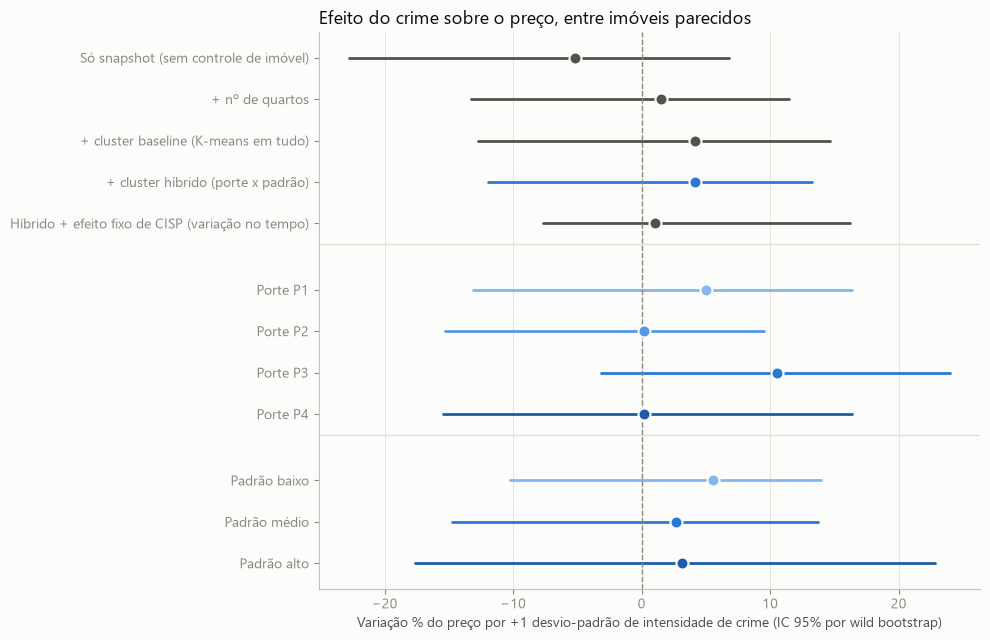

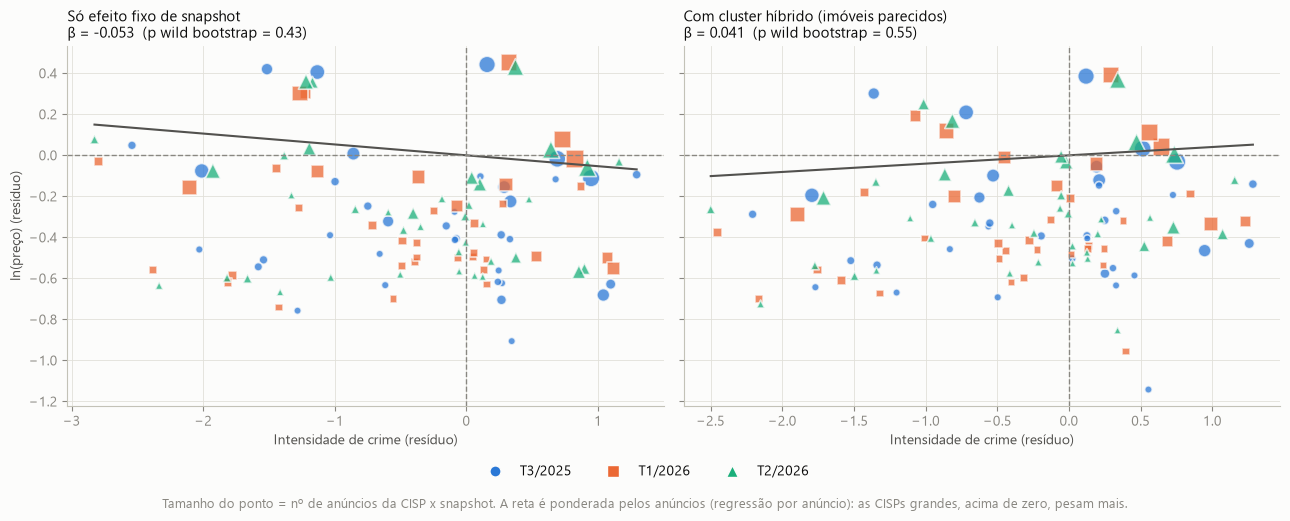

In [19]:
# (a) Forest plot: efeito % do crime sobre o preço, por especificação e por subgrupo.
RAMPA_PADRAO = ["#86b6ef", "#2a78d6", "#1c5cab"]
itens = [
    (nome, r["efeito_pct"], r["pct_inf"], r["pct_sup"], "#2a78d6" if nome.startswith("+ cluster híbrido") else INK_2)
    for nome, r in tabela_reg.iterrows()
]
blocos = [itens]
blocos.append([
    (g, r["efeito_pct"], r["pct_inf"], r["pct_sup"], RAMPA_ORDINAL[int(r["nivel"]) - 1])
    for g, r in heterogeneidade[heterogeneidade["eixo"] == "porte"].iterrows()
])
blocos.append([
    (g, r["efeito_pct"], r["pct_inf"], r["pct_sup"], RAMPA_PADRAO[int(r["nivel"]) - 1])
    for g, r in heterogeneidade[heterogeneidade["eixo"] == "padrao"].iterrows()
])

fig, ax = plt.subplots(figsize=(10, 6.5))
posicoes, rotulos_y, y = [], [], 0.0
for i, bloco in enumerate(blocos):
    for nome, efeito, inf, sup, cor in bloco:
        ax.plot([inf, sup], [y, y], color=cor, linewidth=2, solid_capstyle="round")
        ax.scatter([efeito], [y], s=75, color=cor, edgecolor=SURFACE, linewidth=1.5, zorder=3)
        posicoes.append(y)
        rotulos_y.append(nome)
        y -= 1
    if i < len(blocos) - 1:
        ax.axhline(y + 0.5, color=GRID, linewidth=1)
        y -= 0.6
ax.axvline(0, color=MUTED, linestyle="--", linewidth=1)
ax.set_yticks(posicoes)
ax.set_yticklabels(rotulos_y)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Variação % do preço por +1 desvio-padrão de intensidade de crime (IC 95% por wild bootstrap)")
ax.set_title("Efeito do crime sobre o preço, entre imóveis parecidos", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

# (b) Gráfico de variável adicionada: o que o teorema de Frisch-Waugh-Lovell "enxerga".
# Cada ponto é uma CISP x snapshot (média dos resíduos); a reta tem a inclinação β estimada.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
paineis = [
    ("Só efeito fixo de snapshot", ["periodo"], "Só snapshot (sem controle de imóvel)"),
    ("Com cluster híbrido (imóveis parecidos)", ["periodo", "hibrido"], "+ cluster híbrido (porte x padrão)"),
]
for ax, (titulo, efeitos, nome) in zip(axes, paineis):
    yt, xt = residualizar(reg, efeitos)
    pontos = (
        pd.DataFrame({"cisp": reg["cisp"], "periodo": reg["periodo"], "yt": yt, "xt": xt})
        .groupby(["cisp", "periodo"]).agg(yt=("yt", "mean"), xt=("xt", "mean"), n=("yt", "size")).reset_index()
    )
    for per in periodos:
        d = pontos[pontos["periodo"] == per]
        ax.scatter(d["xt"], d["yt"], s=20 + 150 * np.sqrt(d["n"] / pontos["n"].max()), marker=marca_periodo[per],
                   color=cor_periodo[per], alpha=0.75, edgecolor=SURFACE, linewidth=1.2)
    xs = np.array([pontos["xt"].min(), pontos["xt"].max()])
    ax.plot(xs, tabela_reg.loc[nome, "beta"] * xs, color=INK_2, linewidth=1.5)
    ax.axhline(0, color=MUTED, linestyle="--", linewidth=1)
    ax.axvline(0, color=MUTED, linestyle="--", linewidth=1)
    ax.set_title(f"{titulo}\nβ = {tabela_reg.loc[nome, 'beta']:.3f}  (p wild bootstrap = {tabela_reg.loc[nome, 'p_wcb']:.2f})",
                 fontsize=11, loc="left")
    ax.set_xlabel("Intensidade de crime (resíduo)")
axes[0].set_ylabel("ln(preço) (resíduo)")
fig.legend(handles=legenda, loc="lower center", frameon=False, ncol=3, bbox_to_anchor=(0.5, 0.045))
fig.text(0.5, 0.012, "Tamanho do ponto = nº de anúncios da CISP x snapshot. A reta é ponderada pelos anúncios (regressão por anúncio): "
         "as CISPs grandes, acima de zero, pesam mais.", ha="center", fontsize=9, color=MUTED)
plt.tight_layout(rect=(0, 0.1, 1, 1))
plt.show()

## Leitura dos resultados da Parte 2

Nenhuma especificação encontra efeito do crime sobre o preço (p de 0,43 a 0,83). No modelo híbrido, +1 desvio-padrão de crime está associado a +4% no preço, com IC de −12% a +13%. O teste só detectaria efeitos de cerca de 15% ou mais.